In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [2]:
Amazon_data = pd.read_excel('/content/Amazon 2_Raw.xlsx')

In [3]:
Amazon_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      3203 non-null   object        
 1   Order Date    3203 non-null   datetime64[ns]
 2   Ship Date     3203 non-null   datetime64[ns]
 3   EmailID       3203 non-null   object        
 4   Geography     3203 non-null   object        
 5   Category      3203 non-null   object        
 6   Product Name  3203 non-null   object        
 7   Sales         3203 non-null   float64       
 8   Quantity      3203 non-null   int64         
 9   Profit        3203 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(5)
memory usage: 250.4+ KB


# Amazon.data_Analysis

In [4]:
print(type(Amazon_data))

<class 'pandas.core.frame.DataFrame'>


In [5]:
Amazon_data.shape

(3203, 10)

In [6]:
Amazon_data.isnull().sum()
Amazon_data.duplicated().sum()

np.int64(0)

In [7]:
Amazon_data.describe()

,Order Date,Ship Date,Sales,Quantity,Profit
count,3203,3203,3203.000000,3203.000000,3203.000000
mean,2013-05-10 03:06:07.530440192,2013-05-14 01:25:25.195129600,226.493233,3.828910,33.849032
min,2011-01-07 00:00:00,2011-01-09 00:00:00,0.990000,1.000000,-3399.980000
25%,2012-05-22 00:00:00,2012-05-26 00:00:00,19.440000,2.000000,3.852000
50%,2013-07-22 00:00:00,2013-07-25 00:00:00,60.840000,3.000000,11.166400
75%,2014-05-23 00:00:00,2014-05-27 00:00:00,215.809000,5.000000,33.000400
max,2014-12-31 00:00:00,2015-01-06 00:00:00,13999.960000,14.000000,6719.980800
std,NaN,NaN,524.876877,2.260947,174.109081


Add a column of Year & Month

In [8]:
Amazon_data['Year'] = Amazon_data['Order Date'].dt.year

Amazon_data['Month'] = Amazon_data['Order Date'].dt.month

In [9]:
month_sales = Amazon_data.groupby('Month')['Sales'].sum()


In [10]:
year_sales = Amazon_data.groupby('Year')['Sales'].sum()

In [11]:
Amazon_data['Shipping Days'] = Amazon_data['Ship Date'] - Amazon_data['Order Date']

In [12]:
Amazon_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3203 entries, 0 to 3202
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype          
---  ------         --------------  -----          
 0   Order ID       3203 non-null   object         
 1   Order Date     3203 non-null   datetime64[ns] 
 2   Ship Date      3203 non-null   datetime64[ns] 
 3   EmailID        3203 non-null   object         
 4   Geography      3203 non-null   object         
 5   Category       3203 non-null   object         
 6   Product Name   3203 non-null   object         
 7   Sales          3203 non-null   float64        
 8   Quantity       3203 non-null   int64          
 9   Profit         3203 non-null   float64        
 10  Year           3203 non-null   int32          
 11  Month          3203 non-null   int32          
 12  Shipping Days  3203 non-null   timedelta64[ns]
dtypes: datetime64[ns](2), float64(2), int32(2), int64(1), object(5), timedelta64[ns](1)
memory usage: 300.4+ KB


In [13]:
np.mean(Amazon_data['Sales'])

np.float64(226.49323275054635)

In [14]:
np.max(Amazon_data['Profit'])

6719.9808

In [15]:
np.where(Amazon_data['Profit'] > 0, 'Profit', 'Loss')

array(['Profit', 'Profit', 'Profit', ..., 'Profit', 'Profit', 'Profit'],
      dtype='<U6')

Top 10 Products

In [16]:
top_10_products = Amazon_data.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_10_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          13999.960
High Speed Automatic Electric Letter Opener                                    13100.240
Global Troy Executive Leather Low-Back Tilter                                  10019.600
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     8134.336
GuestStacker Chair with Chrome Finish Legs                                      8030.016
Okidata MB760 Printer                                                           7834.400
Bretford Rectangular Conference Table Tops                                      7710.665
LogitechÂ P710e Mobile Speakerphone                                             7467.210
Canon PC1060 Personal Laser Copier                                              6719.904
Hewlett Packard LaserJet 3310 Copier                                            6239.896
Name: Sales, dtype: float64


Lowest Products

In [51]:
lowest_products = Amazon_data.groupby('Product Name')['Sales'].sum().sort_values(ascending=True).head(10)
print(lowest_products)

Product Name
Colored Push Pins                               1.810
Wilson Jones DublLock D-Ring Binders            2.025
Acco Banker's Clasps, 5 3/4"-Long               2.880
Bagged Rubber Bands                             3.024
Avery 511                                       3.080
Avery 510                                       3.750
Design Ebony Sketching Pencil                   4.170
Acco Economy Flexible Poly Round Ring Binder    4.176
Avery Round Ring Poly Binders                   4.544
Sterling Rubber Bands by Alliance               4.710
Name: Sales, dtype: float64


Top Selling Categories



In [17]:
top_selling_categories = Amazon_data.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(top_selling_categories)

Category
Chairs         101781.3280
Phones          98684.3520
Tables          84754.5620
Storage         70532.8520
Accessories     61114.1160
Binders         55961.1130
Copiers         49749.2420
Machines        42444.1220
Bookcases       36004.1235
Appliances      30236.3360
Furnishings     30072.7300
Paper           26663.7180
Supplies        18127.1220
Art              9212.0660
Labels           5078.7260
Envelopes        4118.1000
Fasteners         923.2160
Name: Sales, dtype: float64


Highest Profit Region

In [47]:
highest_profit_region = Amazon_data.groupby('Geography')['Profit'].sum().sort_values(ascending=False).head(10)
print(highest_profit_region)

Geography
United States,Los Angeles,California      30440.7579
United States,Seattle,Washington          29156.0967
United States,San Francisco,California    17507.3854
United States,San Diego,California         6377.1960
United States,North Las Vegas,Nevada       2247.6899
United States,Sacramento,California        2069.6859
United States,Great Falls,Montana          1582.7071
United States,Des Moines,Washington        1250.3434
United States,Anaheim,California           1234.0036
United States,Brentwood,California         1216.8104
Name: Profit, dtype: float64


# Amazon.data_Visualizations

Text(0.5, 1.0, 'Top 10 Products by Sales')

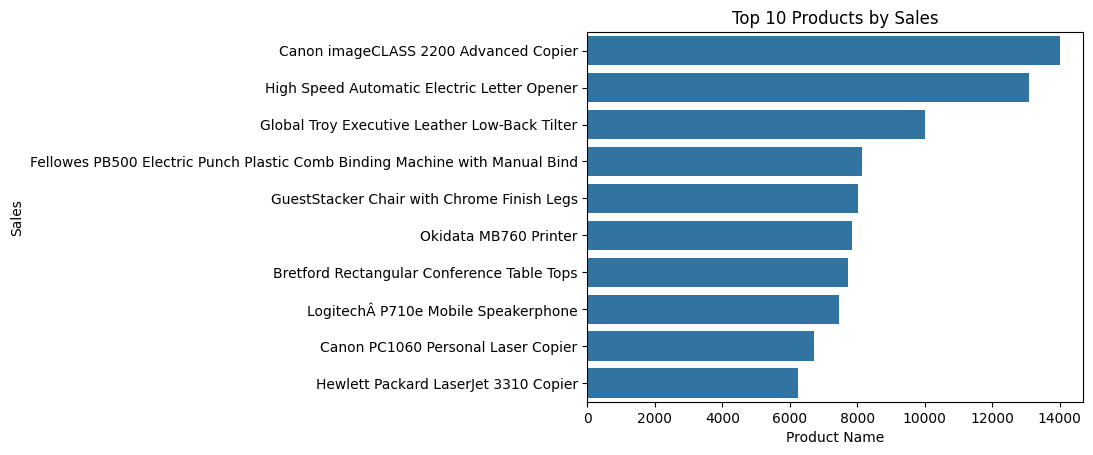

In [36]:
sns.barplot(x=top_10_products.values, y=top_10_products.index)
plt.xlabel('Product Name')
plt.ylabel('Sales')
plt.title('Top 10 Products by Sales')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, 'Chairs'),
  Text(1, 0, 'Phones'),
  Text(2, 0, 'Tables'),
  Text(3, 0, 'Storage'),
  Text(4, 0, 'Accessories'),
  Text(5, 0, 'Binders'),
  Text(6, 0, 'Copiers'),
  Text(7, 0, 'Machines'),
  Text(8, 0, 'Bookcases'),
  Text(9, 0, 'Appliances'),
  Text(10, 0, 'Furnishings'),
  Text(11, 0, 'Paper'),
  Text(12, 0, 'Supplies'),
  Text(13, 0, 'Art'),
  Text(14, 0, 'Labels'),
  Text(15, 0, 'Envelopes'),
  Text(16, 0, 'Fasteners')])

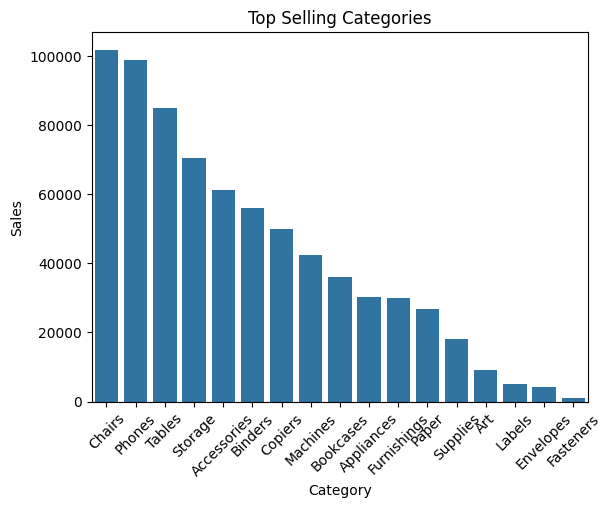

In [22]:
sns.light_palette("green", as_cmap=True)
sns.barplot(x=top_selling_categories.index, y=top_selling_categories.values)
plt.xlabel('Category')
plt.ylabel('Sales')
plt.title('Top Selling Categories')
plt.xticks(rotation=45)


Text(0.5, 1.0, 'Monthly Sales Trend')

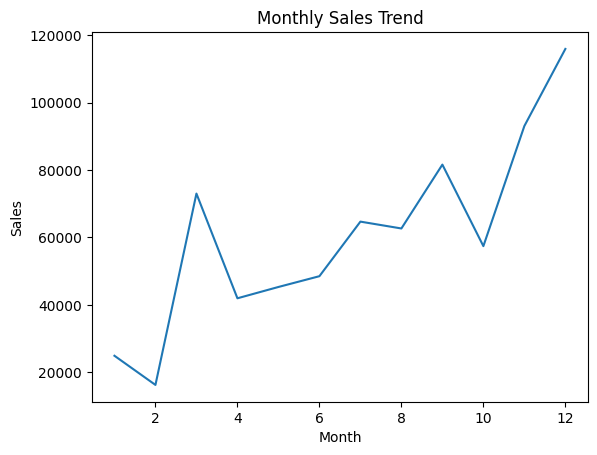

In [21]:
sns.lineplot(x=month_sales.index, y=month_sales.values)
plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Monthly Sales Trend')

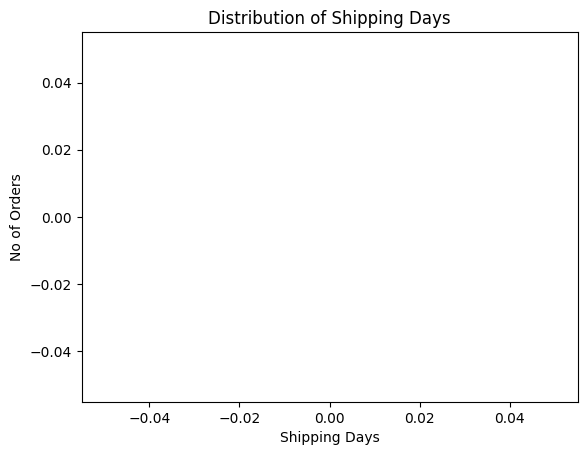

In [40]:
sns.histplot(Amazon_data['Shipping Days'].dtype)
plt.xlabel('Shipping Days')
plt.ylabel('No of Orders')
plt.title('Distribution of Shipping Days')
plt.show()

In [45]:
sns.heatmap(Amazon_data.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()


ValueError: could not convert string to float: 'CA-2013-138688'

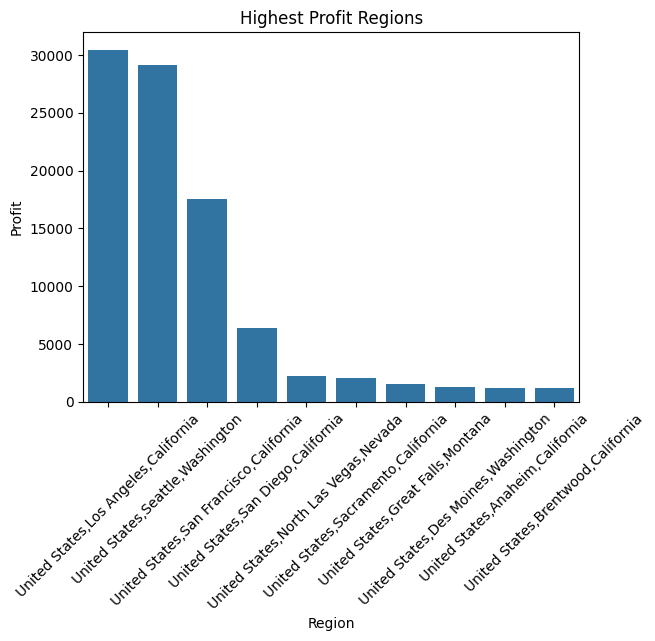

In [56]:
sns.barplot(x=highest_profit_region.index, y=highest_profit_region.values)
plt.xlabel('Region')
plt.ylabel('Profit')
plt.title('Highest Profit Regions')
plt.xticks(rotation=45)
plt.show()

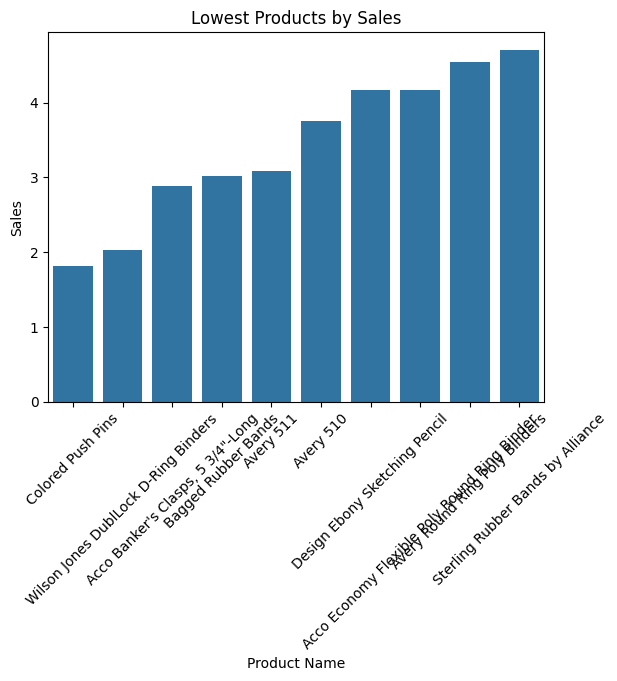

In [57]:
sns.barplot(x=lowest_products.index, y=lowest_products.values)
plt.xlabel('Product Name')
plt.ylabel('Sales')
plt.title('Lowest Products by Sales')
plt.xticks(rotation=45)
plt.show()
